# Variable-mean noise: LN models across a luminance step

**The experiment.** `VariableMeanNoise` delivers Gaussian noise of constant contrast **through
an LED** while the mean light level steps periodically. One epoch therefore contains steps in
both directions, and the question is how the cell's linear-nonlinear model changes as it adapts
to each new mean.

The protocol lives in two packages —
`edu.washington.riekelab.rieke.protocols.VariableMeanNoise` and
`edu.washington.riekelab.turner.protocols.VariableMeanNoise` — and they are the same protocol:
the recorded epoch parameters are identical, verified against the stored epochs rather than
assumed. Both are searched together and `protocol_name` says which one a block came from.


Model fitting is **cascadegraph**, vendored at `retinanalysis.utils.cascadegraph` — the Python
port of the library the MATLAB used. Nothing here reimplements a filter or a sigmoid.

In [1]:
import contextlib
import io
import json
import sys
import time
from pathlib import Path

if sys.version_info[:2] != (3, 11):
    raise RuntimeError(
        f'This notebook requires the retinanalysis Python 3.11 kernel; '
        f'got Python {sys.version.split()[0]} at {sys.executable}')
import_started = time.perf_counter()

import numpy as np
import pandas as pd
from IPython.display import display

import retinanalysis as ra
from retinanalysis.SCutils import explore as sc

# The analysis module sits beside this notebook: it is specific to this project.
sys.path.insert(0, str(Path.cwd()))
import variable_mean_noise as vmn

print(f'Python {sys.version.split()[0]} | {sys.executable}')
print(f'Imports ready in {time.perf_counter() - import_started:.2f} s')

Python 3.11.13 | /Users/chrischen/opt/anaconda3/envs/retinanalysis/bin/python
Imports ready in 0.58 s


## 1. Find experiment dates and cells

Discovery over both package copies of the protocol. A block is kept only if it can answer the
question this protocol asks:

- **`stimTime` ≥ 30 s** — the mean steps part-way through, so a short epoch has no post-step
  stretch to fit. The protocol's default is 600 ms and most recorded blocks are short runs.
- **primate ganglion cells only** — ON/OFF parasol, ON/OFF midget, AII. Cones, horizontals and
  unlabelled cells are a different experiment.
- **more than one light mean** — a cell that only ever saw one mean has no step to measure.
- **one noise contrast** — a filter pooled across contrasts describes neither.

`cell_index` is the handle to copy into §2, so the cell label never has to be typed. Rows are
grouped by experiment.

`n_extracellular` / `n_exc` / `n_inh` come from the recording-type check below, and are the
column that says whether a cell is worth opening and in which mode. **One cell often has blocks
of more than one type** — held cell-attached for one and whole-cell for the next — and those are
never fitted together.

### 1a. Recording type per block

These blocks carry no `onlineAnalysis`, so the amplifier decides. The epoch group's
`recordingTechnique` settles most of them; where it does not, series resistance above zero means
whole-cell with the polarity from the sign of the current (inward is `exc`, outward `inh`), and a
reading of exactly zero is confirmed against the trace, since it also happens when compensation
was never run.

Resolving a block that needs its trace is seconds per block, so this is **cached** to
`block_modes.csv` beside the notebook. Set `REFRESH_MODE_CACHE = True` to rebuild it (a few
minutes over ~400 blocks); otherwise it is read from disk.

In [2]:
REFRESH_MODE_CACHE = False

protocol_blocks = vmn.find_blocks(show=True, height=0)

if REFRESH_MODE_CACHE or not vmn.MODE_CACHE_PATH.exists():
    print(f'\nbuilding {vmn.MODE_CACHE_PATH.name} — a few minutes ...')
    rows = []
    for n, block_id in enumerate(protocol_blocks.block_id, 1):
        exp_name = protocol_blocks.loc[
            protocol_blocks.block_id.eq(block_id), 'exp_name'].iloc[0]
        rows.append(dict(exp_name=exp_name, block_id=int(block_id),
                         n_epochs=len(vmn.epoch_parameters(int(block_id))),
                         **vmn.resolve_block_mode(exp_name, int(block_id))))
        if n % 50 == 0:
            print(f'  {n}/{len(protocol_blocks)}')
    pd.DataFrame(rows).to_csv(vmn.MODE_CACHE_PATH, index=False)

block_modes = vmn.load_block_modes()
print(f'\nrecording types over {len(block_modes)} cached blocks:')
print(block_modes.rec_type.value_counts(dropna=False).to_string())

373 blocks | 46 experiments | 182 cells
  dropped 1227 block(s) with stimTime < 30 s
  dropped 120 block(s) on non-primate-RGC cell types
  by protocol: edu.washington.riekelab.rieke.protocols.VariableMeanNoise 262, edu.washington.riekelab.turner.protocols.VariableMeanNoise 111


exp_name,cell_label,cell_type_short,block_id,stim_seconds,led,ndfs,frequencyCutoff,numberOfFilters,Contrast,n_epochs,protocol_name
2020-06-11_B,Cell10,ON-parasol,30238,30.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,14,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell11,ON-midget,30209,60.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,2,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell11,ON-midget,30210,60.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,20,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell12,OFF-parasol,30188,30.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,15,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell13,ON-parasol,30174,30.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,19,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell13,ON-parasol,30177,30.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,6,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell14,ON-parasol,30216,30.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,14,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell14,ON-parasol,30218,30.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,27,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-16_B,Cell3,ON-parasol,30318,60.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,10,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-16_B,Cell3,ON-parasol,30319,30.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,11,edu.washington.riekelab.rieke.protocols.VariableMeanNoise



recording types over 373 cached blocks:
rec_type
extracellular    165
exc              116
none              76
inh               16


In [3]:
protocol_cells = vmn.find_protocol_cells(protocol_blocks, modes=block_modes,
                                        show=True, height=460)

125 cells across 35 experiments
  dropped 54 cell(s) that ran only one light mean
  dropped 3 cell(s) that ran more than one contrast


exp_name,cell_index,cell_label,cell_type,n_extracellular,n_exc,n_inh,light_means,light_contrast,stim_seconds,led
2020-06-11_B,0,Cell10,ON-parasol,0,14,0,"0.3, 3",0.5,30,UV LED
,1,Cell11,ON-midget,0,22,0,"0.3, 3",0.5,60,UV LED
,2,Cell12,OFF-parasol,15,0,0,"0.3, 3",0.5,30,UV LED
,3,Cell13,ON-parasol,19,6,0,"0.3, 3",0.5,30,UV LED
,4,Cell14,ON-parasol,14,27,0,"0.3, 3",0.5,30,UV LED
2020-06-16_B,5,Cell3,ON-parasol,21,53,0,"0.08, 0.3, 0.8, 3",0.5,"30, 60",UV LED
2020-06-23_B,6,Cell10,OFF-parasol,10,0,0,"0.3, 3",0.5,30,UV LED
,7,Cell8,ON-midget,20,0,0,"0.1, 1",0.5,30,UV LED
2021-02-01_B,8,cell1,ON-parasol,62,0,0,"0.05, 0.08, 0.5, 1, 5",0.5,30,UV LED
,9,cell2,ON-midget,0,31,0,"0.05, 0.5, 5",0.5,30,UV LED


## 2. Analyze one cell condition

Set `CELL_INDEX` from §1 and `REC_TYPE` to the mode you want (`extracellular`, `exc` or `inh`).

**Then the model.** Symphony stores the noise generator's parameters and seed, not the waveform,
so `gaussian_noise_stimulus` rebuilds it — MATLAB's `RandStream` `randn` matches no NumPy
generator, so the Gaussian draw comes from the MATLAB engine and **this section needs it**.

Three things about the fit:

- the stimulus stays in **raw intensity**, so its contrast is `sigma / mean` — the protocol's
  own `Contrast`;
- the filter is divided by `contrast_generator / contrast_stimulus`. The generator signal is a
  convolution of the filter with the stimulus, so that ratio is exactly the factor by which the
  filter inflates its contrast; dividing it out leaves the generator with the **same
  `sigma / mean` as the stimulus**, which is what makes the nonlinearity's x axis the same
  contrast axis at every light level. The filter is *not* peak-normalised, so its amplitude is
  whatever that normalisation leaves;

The nonlinearity is sampled with **equal-N bins** — the same number of points in every bin, as
`SETTINGS.binningType = 'equalN'` does. Equal-width bins put almost nothing in the tails, which
is exactly where the nonlinearity saturates, so the fit gets pulled around by a handful of
samples out there.

**Whole-cell recordings — `exc` and `inh` — need two more guards.** Neither runs for an
`extracellular` recording whatever it is passed: that response is a spike rate built from spike
times, with no holding current to wander and no series resistance to refuse on, and
`analyze_condition` prints which way it resolved on its first line. The holding
current wanders over a long recording — on `2021-04-27_B cell1` the epoch means span 1741 pA
while the modulation within an epoch is about 300 pA, so the offset is roughly five times the
signal, and the model cannot explain any of it because the stimulus says nothing about it.

- **`MAX_SERIES_RESISTANCE`** drops epochs whose recorded series resistance is above it; what
  went is printed and kept in `analysis.dropped_epochs`.
- **`ALIGN_EPOCH_MEANS`** shifts each epoch so its mean matches the *median* of the epoch means
  **within its own light mean** — per light mean because the two genuinely differ in holding
  current, and the median so one badly drifted epoch cannot drag the level the others are judged
  against. The shifts are printed and kept in `analysis.epoch_adjustments`.

Without the alignment that cell's exc fits score r² −7.6 and −6.6; with it, +0.64 and +0.72.

One LN model is fitted per light mean. Scoring holds out 20% of epochs on each of three rounds

2026-02-27_G | Cell1 (ON-parasol) | UV LED | lightMean 0.03, 0.3 | contrast 0.3 | 30 s
epochs: 0 extracellular, 15 exc, 0 inh

fitting exc blocks [37101, 37104]


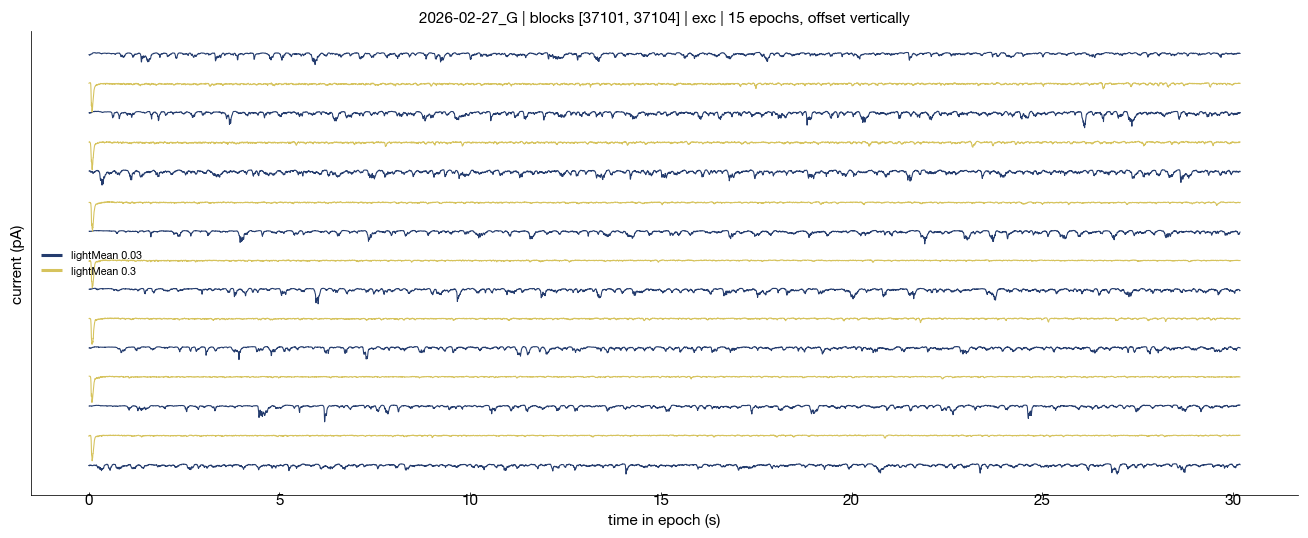

In [4]:
CELL_INDEX = 122
REC_TYPE = 'exc'   # 'extracellular', 'exc' or 'inh'
SKIP_SECONDS = 1.0           # drop the settling period at the start of each epoch
MAX_EPOCHS = None              # None for every epoch
DOWNSAMPLE = 10              # 10 kHz -> 1 kHz, by block average
WINDOW_SECONDS = 6.0         # how much of an epoch each data/model row shows

row = protocol_cells[protocol_cells.cell_index.eq(CELL_INDEX)].iloc[0]
print(f'{row.exp_name} | {row.cell_label} ({row.cell_type}) | {row.led} | '
      f'lightMean {row.light_means} | contrast {row.light_contrast} | '
      f'{row.stim_seconds} s')
print(f'epochs: {row.n_extracellular} extracellular, {row.n_exc} exc, {row.n_inh} inh')

EXP_NAME, BLOCK_IDS, rec_type = vmn.cell_blocks(
    protocol_cells, CELL_INDEX, rec_type=REC_TYPE, modes=block_modes)
print(f'\nfitting {rec_type} blocks {BLOCK_IDS}')

trace_figure = vmn.plot_traces(EXP_NAME, BLOCK_IDS, rec_type, max_epochs=MAX_EPOCHS)

exc: whole-cell drift guards apply -- series-resistance limit 30 MOhm, align epoch means on


  lightMean 0.03: 8 epochs (6 train / 2 test) | r²=0.608 held out, 0.660 in sample | time-to-peak 212 ms


  lightMean 0.3: 7 epochs (5 train / 2 test) | r²=0.531 held out, 0.520 in sample | time-to-peak 266 ms

  aligned 15 epoch(s) to the median holding current of their light mean:
    lightMean 0.03: target -354 pA | offsets -171 to +42 pA
    lightMean 0.3: target -316 pA | offsets -98 to +35 pA


,block_id,epoch,light_mean,series_resistance_mohm,mean_before_pa,offset_pa,mean_after_pa
0,37101,0,0.0,8.2,-396.3,41.9,-354.4
1,37101,2,0.0,8.2,-359.0,4.5,-354.4
2,37101,4,0.0,8.2,-349.9,-4.5,-354.4
3,37101,6,0.0,8.2,-370.3,15.9,-354.4
4,37101,8,0.0,8.2,-387.1,32.7,-354.4
5,37104,0,0.0,8.2,-281.8,-72.6,-354.4
6,37104,2,0.0,8.2,-251.3,-103.1,-354.4
7,37104,4,0.0,8.2,-183.7,-170.7,-354.4
8,37101,1,0.3,8.2,-332.8,16.5,-316.3
9,37101,3,0.3,8.2,-302.6,-13.7,-316.3



<ConditionAnalysis 2026-02-27_G blocks=[37101, 37104] | exc | lightMean 0.03, 0.3>


/Users/chrischen/Documents/GitHub/retinanalysis/SingCell_Notebooks/rodAdaptation/variable_mean_noise.py:2127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.98))


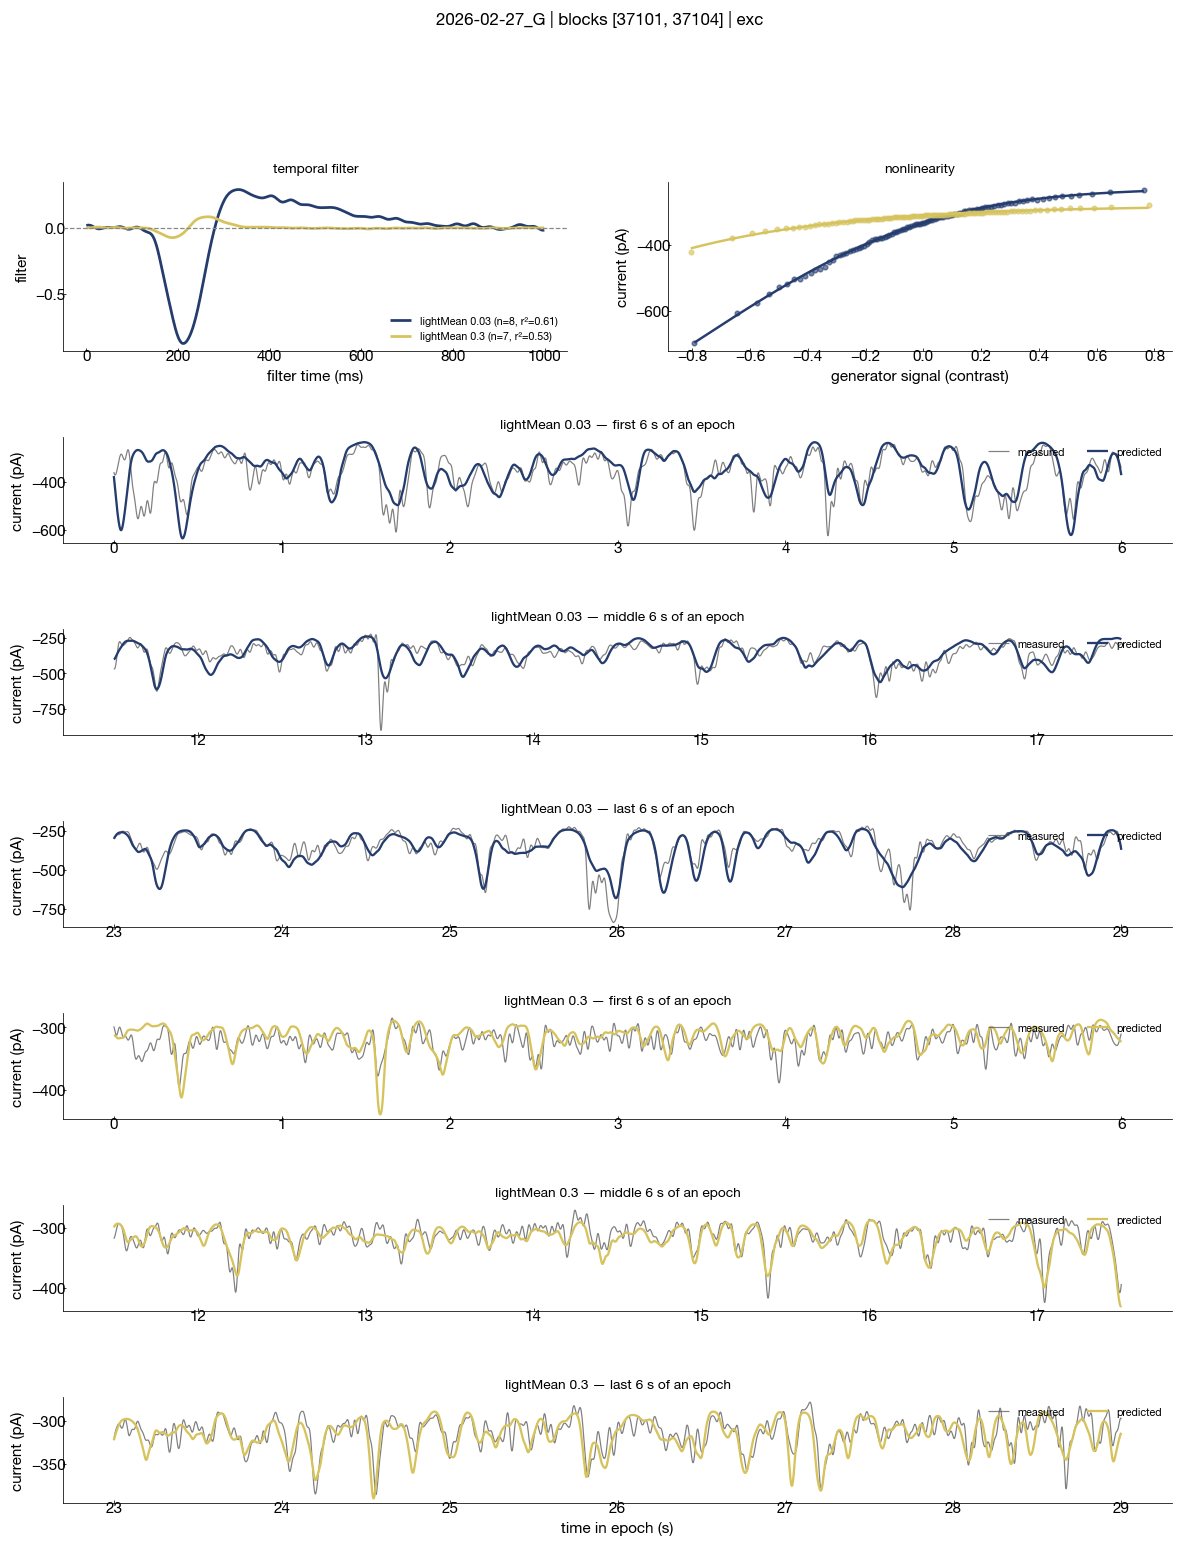

In [5]:
# exc / inh only -- neither runs for an extracellular recording, whatever is set here.
MAX_SERIES_RESISTANCE = 30e6   # drop epochs above this (ohms); None to keep all
ALIGN_EPOCH_MEANS = True       # bring epochs onto a common holding current

analysis = vmn.analyze_condition(
    EXP_NAME, BLOCK_IDS, rec_type=rec_type, skip_seconds=SKIP_SECONDS,
    downsample=DOWNSAMPLE, max_epochs=MAX_EPOCHS,
    max_series_resistance=MAX_SERIES_RESISTANCE,
    align_epoch_means=ALIGN_EPOCH_MEANS, verbose=True)

if len(analysis.dropped_epochs):
    display(analysis.dropped_epochs)
if len(analysis.epoch_adjustments):
    display(analysis.epoch_adjustments.round(1))
print(f'\n{analysis}')

condition_figure = vmn.plot_condition(analysis, window_seconds=WINDOW_SECONDS)

### 2a. The adaptation

**Time-to-peak** is the reading to take from this: a cell adapted to a dimmer mean integrates
for longer. `biphasic_index` is the other shape number — +1 for a purely monophasic filter, 0
when the two lobes are equal.

`r2` is held out, `r2_train` in sample, and `nl_r2` is the sigmoid's fit to the binned
nonlinearity points — **not** model performance, shown only so it is not mistaken for it.

In [6]:
rows = []
for mean_level in analysis.light_means:
    model = analysis.ln_model[mean_level]
    rows.append({
        'lightMean': mean_level,
        'n_epochs': analysis.n_epochs[mean_level],
        'n_train': model.n_train, 'n_test': model.n_test,
        'r2': model.r2, 'r2_train': model.r2_train, 'nl_r2': model.nl_r2,
        'time_to_peak_ms': model.time_to_peak_ms,
        'biphasic_index': model.biphasic_index,
    })
summary = pd.DataFrame(rows)
display(summary.round(3))

if len(summary) > 1:
    dim, bright = summary.iloc[0], summary.iloc[-1]
    print(f'lightMean {dim.lightMean:g} -> {bright.lightMean:g}  '
          f'({bright.lightMean / dim.lightMean:.0f}x brighter):')
    print(f'  time-to-peak   {dim.time_to_peak_ms:.0f} -> {bright.time_to_peak_ms:.0f} ms')
    print(f'  biphasic index {dim.biphasic_index:+.2f} -> {bright.biphasic_index:+.2f}')

,lightMean,n_epochs,n_train,n_test,r2,r2_train,nl_r2,time_to_peak_ms,biphasic_index
0,0.03,8,6,2,0.608,0.66,0.999,212.0,-0.501
1,0.30,7,5,2,0.531,0.52,0.992,266.0,0.074


lightMean 0.03 -> 0.3  (10x brighter):
  time-to-peak   212 -> 266 ms
  biphasic index -0.50 -> +0.07


### 2b. Group mean response

Every epoch has its own noise seed, so no two responses are alike — but they share the light
mean and the time since it stepped, and that is the axis adaptation runs along. Averaging across
the epochs of one light mean, then within `MEAN_WINDOW_S` windows, leaves the slow course of the
rate with the noise-driven modulation averaged out.

The mean is constant *within* an epoch and changes *between* them, so time-in-epoch is
time-since-step. Note this starts at `SKIP_SECONDS`: to see the very beginning of the
adaptation, set `SKIP_SECONDS = 0` in §2 and re-run.

,windows,first_s,last_s,mean_rate,n_epochs
light_mean,,,,,
0.03,29,1.5,29.5,-354.42,8
0.30,29,1.5,29.5,-316.28,7


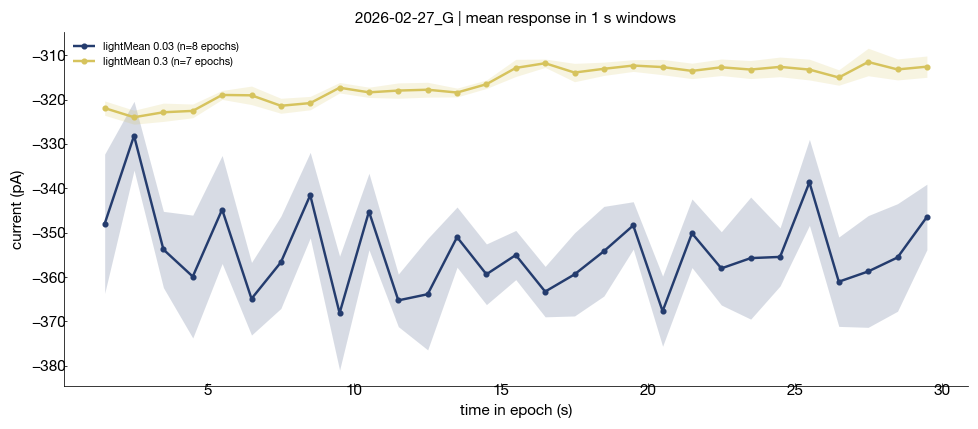

In [7]:
MEAN_WINDOW_S = 1.0

mean_trace = vmn.mean_response(analysis, window_s=MEAN_WINDOW_S)
mean_response_figure = vmn.plot_mean_response(analysis, window_s=MEAN_WINDOW_S)

display(mean_trace.groupby('light_mean').agg(
    windows=('time_s', 'size'), first_s=('time_s', 'min'), last_s=('time_s', 'max'),
    mean_rate=('mean', 'mean'), n_epochs=('n_epochs', 'max')).round(2))

### 2c. How the model changes over the epoch

`temporalLNModel.m` cuts the fitted stretch into successive windows and fits the model
separately in each, so the filter and the nonlinearity can be watched changing as the cell
adapts. Epochs are pooled within a window — all the first five seconds together, then all the
second five — because one epoch's window is nowhere near enough data for a filter.

Windows are a fixed `TEMPORAL_WINDOW_S` rather than a fixed count, so the same setting means the
same thing on a 30 s and a 60 s epoch; the last partial window is dropped. The filter length is
capped at half the window, since a 1 s filter cannot be estimated from a 1 s window.

Windows run dark to light within each panel, so a filter that speeds up or a nonlinearity that
steepens reads as a progression rather than a pile of lines.

  lightMean 0.03         1-6 s: r²=0.420 | time-to-peak 209 ms
  lightMean 0.03        6-11 s: r²=0.541 | time-to-peak 202 ms
  lightMean 0.03       11-16 s: r²=0.591 | time-to-peak 203 ms


  lightMean 0.03       16-21 s: r²=0.539 | time-to-peak 216 ms
  lightMean 0.03       21-26 s: r²=0.377 | time-to-peak 475 ms


  lightMean 0.3         1-6 s: r²=0.286 | time-to-peak 163 ms


  lightMean 0.3        6-11 s: r²=0.404 | time-to-peak 385 ms


  lightMean 0.3       11-16 s: r²=0.377 | time-to-peak 251 ms


  lightMean 0.3       16-21 s: r²=0.485 | time-to-peak 282 ms


  lightMean 0.3       21-26 s: r²=0.448 | time-to-peak 268 ms


,lightMean,window,order,r2,time_to_peak_ms,biphasic_index
0,0.03,1-6 s,0,0.420,209.0,-0.266
1,0.03,6-11 s,1,0.541,202.0,-0.509
2,0.03,11-16 s,2,0.591,203.0,-0.358
3,0.03,16-21 s,3,0.539,216.0,-0.144
4,0.03,21-26 s,4,0.377,475.0,0.002
5,0.30,1-6 s,0,0.286,163.0,-0.134
6,0.30,6-11 s,1,0.404,385.0,0.019
7,0.30,11-16 s,2,0.377,251.0,0.099
8,0.30,16-21 s,3,0.485,282.0,0.034
9,0.30,21-26 s,4,0.448,268.0,0.055


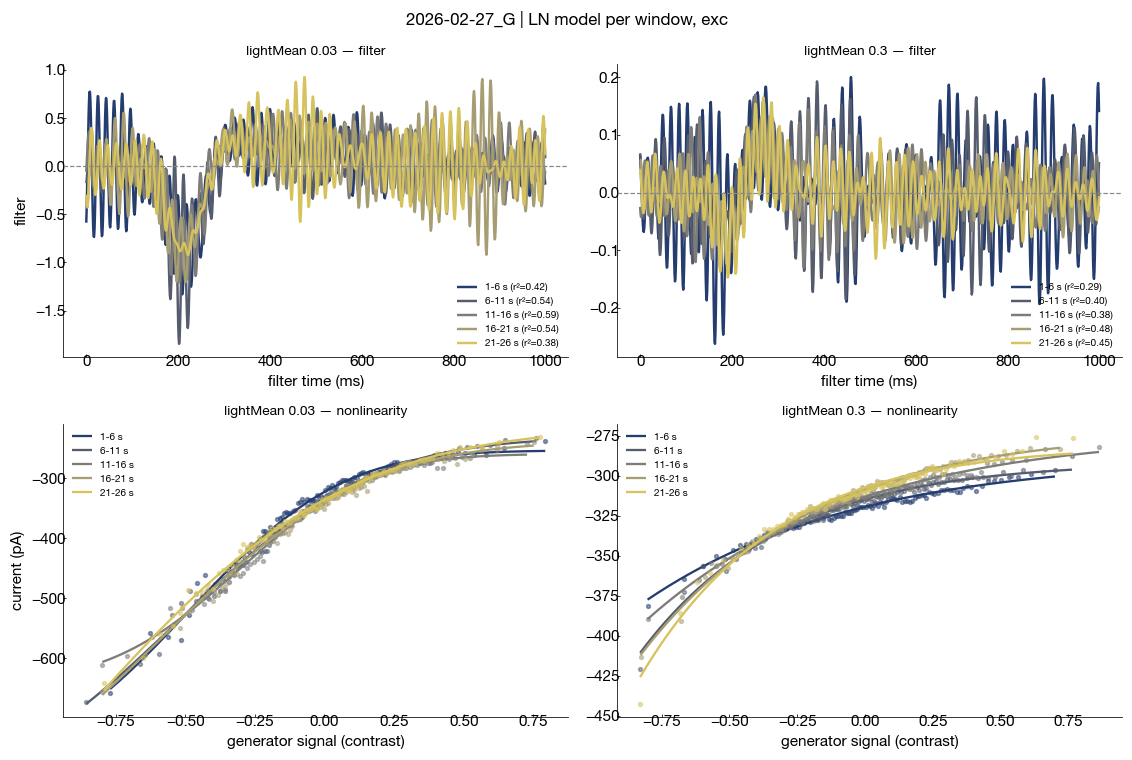

In [8]:
TEMPORAL_WINDOW_S = 5.0

temporal_models = vmn.temporal_ln_model(
    analysis, window_seconds=TEMPORAL_WINDOW_S, verbose=True)
temporal_figure = vmn.plot_temporal_ln(analysis, temporal_models)

rows = []
for mean_level, models in temporal_models.items():
    for order, model in enumerate(models):
        rows.append({'lightMean': mean_level, 'window': model.label,
                     'order': order, 'r2': model.r2,
                     'time_to_peak_ms': model.time_to_peak_ms,
                     'biphasic_index': model.biphasic_index})
temporal_summary = pd.DataFrame(rows)
display(temporal_summary.round(3))

## 3. LED light level

The LED's own neutral density filters set the light level. A `FilterWheel` NDF is real — the
wheel exists on the rig — but it is **not in the LED's path**, so it must not be added to this
stimulus's attenuation. `led_attenuation` returns it separately with `wheel_ignored` set, rather
than dropping it silently, because the same metadata is correct for a Stage protocol and wrong
here.

A filter with no entry in the rig's LED table leaves `optical_density` blank and is named in
`unknown_tokens`, so an unknown filter cannot masquerade as no attenuation.

In [9]:
light_rows = []
for (exp_name, led), group in protocol_blocks.groupby(['exp_name', 'led'], dropna=False):
    entry = vmn.led_attenuation(group.iloc[0])
    entry['n_blocks'] = len(group)
    light_rows.append(entry)
light = pd.DataFrame(light_rows)

sc.scroll_table(
    light[['exp_name', 'rig', 'led', 'led_ndfs', 'optical_density', 'attenuation',
           'wheel_tokens_ignored', 'unknown_tokens', 'n_blocks']].round(4),
    height=340, num_cols=('optical_density', 'attenuation', 'n_blocks'))

unresolved = light[light.unknown_tokens.ne('')]
print(f'{len(light)} experiment x LED combinations | '
      f'{int(light.wheel_ignored.sum())} list an FW filter that is not in the LED path '
      f'(stripped, and named in wheel_tokens_ignored)')
if len(unresolved):
    print(f'{len(unresolved)} with filters missing from the rig LED table: '
          f'{sorted(set(unresolved.unknown_tokens))}')

exp_name,rig,led,led_ndfs,optical_density,attenuation,wheel_tokens_ignored,unknown_tokens,n_blocks
2020-06-11_B,two_photon,UV LED,B4,2.54,0.0029,FW2,,8
2020-06-16_B,two_photon,UV LED,B4,2.54,0.0029,FW2,,8
2020-06-23_B,two_photon,UV LED,(none),0.0,1.0,,,3
2020-07-13_G,shared_two_photon,Red LED,(none),0.0,1.0,,,3
2020-07-14_G,shared_two_photon,Red LED,(none),0.0,1.0,,,8
2020-07-29_G,shared_two_photon,UV LED,(none),0.0,1.0,,,18
2020-08-11_G,shared_two_photon,UV LED,(none),0.0,1.0,,,17
2020-08-25_G,shared_two_photon,UV LED,(none),0.0,1.0,,,8
2020-08-25_G_scotopic,shared_two_photon,UV LED,"G7, G8, G9",4.07,0.0001,,,4
2020-10-20_G,shared_two_photon,UV LED,(none),0.0,1.0,,,6


46 experiment x LED combinations | 2 list an FW filter that is not in the LED path (stripped, and named in wheel_tokens_ignored)
7 with filters missing from the rig LED table: ['E7', 'G5']


## 4. The saved MATLAB summary, for comparison

`matlabSummary/rodVariableMeanNoise.mat` holds the 53 cells the MATLAB analysis was run on,
with its own fitted LN models. It is **not** an input to anything above — the analysis here runs
from the recordings. It is kept so the Python population summary can be compared against the
MATLAB's once there is one.

One thing to know when matching them up: the saved `expDate` is **two days early**, across the
board. `vmn.resolve_roster_files` applies that correction and confirms each cell by label
(case-sensitively) and type; `vmn.SAVED_DATE_OFFSET_DAYS` is the constant. That is only needed
for the comparison, so it is not run here.

In [10]:
roster = vmn.load_summary(show=True)

sc.scroll_table(
    roster[['index', 'exp_date', 'cell_label', 'cell_type', 'rec_type',
            'epoch_len_ms', 'tau_low', 'tau_high', 'is_example']].round(2),
    height=300, num_cols=('index', 'epoch_len_ms', 'tau_low', 'tau_high'))

print(f'\nsaved dates are {vmn.SAVED_DATE_OFFSET_DAYS} days early; '
      f'vmn.resolve_roster_files() corrects and confirms them when needed.')

53 saved cells | 16 dates | 15 rows in duplicated groups
rec_type   exc  extracellular
cell_type                    
OnMidget    11             10
OnParasol   14             18


index,exp_date,cell_label,cell_type,rec_type,epoch_len_ms,tau_low,tau_high,is_example
0,2020/07/27,cell5,OnParasol,extracellular,60000.0,11.87,15.94,False
1,2020/08/23,cell3,OnParasol,extracellular,55000.0,10.59,14.76,True
2,2020/08/23,cell6,OnParasol,extracellular,56000.0,9.07,0.05,True
3,2020/08/23,cell7,OnParasol,extracellular,60000.0,7.33,25909.59,True
4,2020/08/09,cell1,OnMidget,extracellular,60000.0,7.38,12.81,False
5,2020/08/09,cell3,OnParasol,extracellular,50000.0,9.54,12.29,False
6,2020/08/23,cell4,OnMidget,extracellular,55000.0,16.2,14.03,False
7,2021/04/25,cell1,OnParasol,extracellular,50000.0,7.0,7.65,True
8,2021/04/25,cell2,OnParasol,extracellular,50000.0,5.53,39.91,True
9,2021/04/25,cell3,OnParasol,extracellular,50000.0,6.06,28.17,True



saved dates are 2 days early; vmn.resolve_roster_files() corrects and confirms them when needed.
